# **Predicción del Precio de viviendas**

### Carga de funciones

In [1]:
import pandas as pd # Dataframes
import numpy as np # Arreglos y matrices
import scipy.stats as stats
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt # Graficos
import seaborn as sns  # para análisis gráficos
import random # para generar aleatorios
from sklearn.ensemble import IsolationForest # para retiro de outlier de forma multivariada
from sklearn.linear_model import ElasticNet

In [2]:
# cada vez que se guarde .py, Jupyter lo recargue automáticamente
%load_ext autoreload
%autoreload 2

Información del atributo (en orden):

Los datos del precio de la vivienda se han utilizado en muchos documentos de aprendizaje automático que abordan la regresión

- **CRIM**: tasa de criminalidad per cápita por ciudad
- **ZN**: proporción de tierra residencial dividida en zonas para lotes de más de 25,000 pies cuadrados.
- **INDUS**: proporción de acres de negocios no minoristas por ciudad
- **CHAS**: variable ficticia Charles River (= 1 si el tramo limita con el río; 0 en caso contrario)
- **NOX**: concentración de óxidos nítricos (partes por 10 millones)
- **RM**: número medio de habitaciones por vivienda
- **TAX**:tasa de impuesto a la propiedad de valor total
- **EDAD**: proporción de unidades ocupadas por el propietario construidas antes de 1940
- **DIS**: distancias ponderadas a cinco centros de empleo
- **RAD**: índice de accesibilidad a autopistas radiales
- **IMPUESTO**: tasa impositiva sobre el valor total de la propiedad por 10,000
- **PTRATIO**: relación alumno-maestro por localidad
- **B**: 1000 (Bk - 0.63) ^ 2 donde Bk es la proporción de migrantes por ciudad
- **LSTAT**:% menor estado de la población
- **MEDV**: valor medio de viviendas ocupadas por el propietario en $ 1000

### Carga de datos

In [3]:
vivienda = pd.read_csv("../data/raw/vivienda.csv")
vivienda.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
# Eliminar una columna
vivienda = vivienda.drop('Unnamed: 0', axis=1)
vivienda.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


In [4]:
vivienda.shape

(459, 15)

# **1. Análisis Descriptivo**

In [5]:
# Trasformamos al tipo de variable correcto
vivienda['CHAS'] = vivienda['CHAS'].astype('object')

In [6]:
var_numerics = vivienda.select_dtypes(include=['number']).columns.tolist()
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE']

In [7]:
vivienda.describe() # describe es una funcion para tener un reporte estadistico basico rapidamente

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.00000,459.000000,459.000000,459.000000
mean,3.568016,12.527233,10.532549,0.549938,6.305691,67.772767,3.909653,8.851852,390.427015,18.28671,355.029651,12.445773,22.880610
std,8.930732,24.189816,6.738346,0.119705,0.720359,28.883597,2.171832,8.278441,159.966224,2.19928,93.797691,7.296410,9.491573
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.60000,0.320000,1.730000,5.000000
25%,0.076890,0.000000,4.930000,0.447000,5.888000,42.150000,2.058100,4.000000,277.000000,16.80000,375.425000,6.700000,17.050000
50%,0.228760,0.000000,8.140000,0.520000,6.223000,76.900000,3.421700,5.000000,311.000000,18.60000,391.130000,10.560000,21.600000
75%,2.322445,20.000000,18.100000,0.631000,6.635000,94.300000,5.400700,8.000000,437.000000,20.20000,396.025000,16.820000,26.600000
max,88.976200,100.000000,25.650000,0.871000,8.780000,100.000000,12.126500,24.000000,666.000000,22.00000,396.900000,37.970000,50.000000


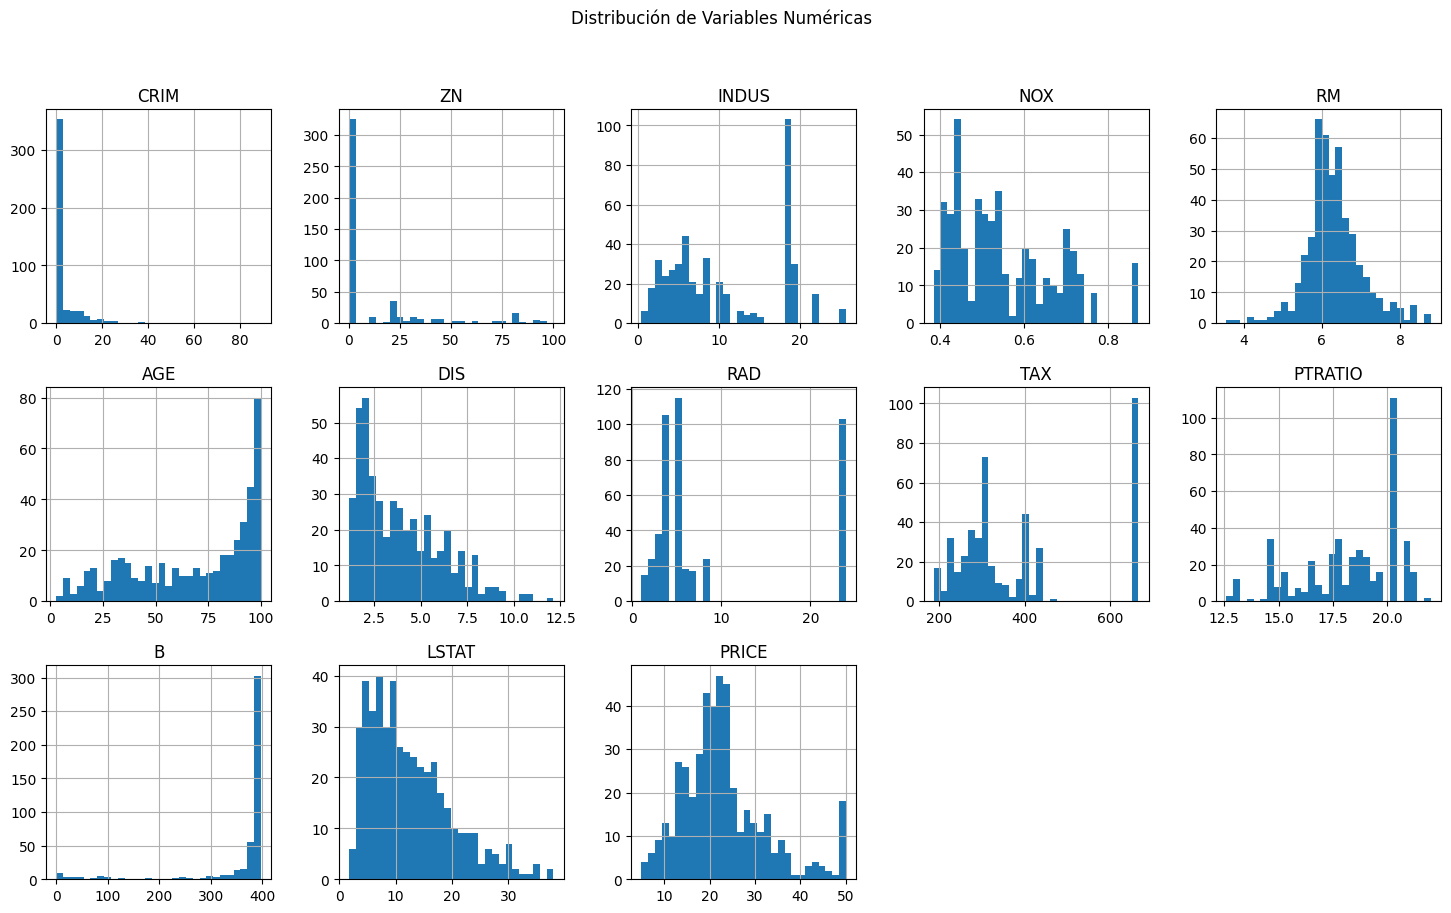

In [8]:
vivienda[var_numerics].hist(figsize=(18, 10), layout=(3,5), bins=30)
plt.suptitle('Distribución de Variables Numéricas')
plt.show()

In [9]:
import sys
sys.path.append("../src")

from preprocessing import imputar_valores_extremos, analizar_distribucion, obtener_correlaciones

In [10]:
# Antes de poder realizar el modelo de regresión lineal debemos ver si existe asociación y de qué tipo es.
# coeficiente de correlación
vivienda[var_numerics].corr()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.202616,0.427685,0.427651,-0.226822,0.359031,-0.389402,0.652669,0.622398,0.297041,-0.396768,0.466295,-0.397261
ZN,-0.202616,1.000000,-0.531240,-0.511010,0.308333,-0.575651,0.657429,-0.305073,-0.294540,-0.370046,0.190713,-0.414955,0.352278
INDUS,0.427685,-0.531240,1.000000,0.785093,-0.393571,0.658919,-0.716299,0.598652,0.686797,0.344381,-0.398493,0.614933,-0.476402
NOX,0.427651,-0.511010,0.785093,1.000000,-0.302923,0.742449,-0.770900,0.639784,0.692935,0.165496,-0.395218,0.599103,-0.422701
RM,-0.226822,0.308333,-0.393571,-0.302923,1.000000,-0.246665,0.193969,-0.227709,-0.291109,-0.358313,0.135343,-0.608563,0.696222
AGE,0.359031,-0.575651,0.658919,0.742449,-0.246665,1.000000,-0.753934,0.491326,0.526643,0.248994,-0.283294,0.609203,-0.365332
DIS,-0.389402,0.657429,-0.716299,-0.770900,0.193969,-0.753934,1.000000,-0.524053,-0.542715,-0.200938,0.312367,-0.496431,0.232413
RAD,0.652669,-0.305073,0.598652,0.639784,-0.227709,0.491326,-0.524053,1.000000,0.928195,0.457461,-0.501840,0.523739,-0.404968
TAX,0.622398,-0.294540,0.686797,0.692935,-0.291109,0.526643,-0.542715,0.928195,1.000000,0.433385,-0.506508,0.558139,-0.474569
PTRATIO,0.297041,-0.370046,0.344381,0.165496,-0.358313,0.248994,-0.200938,0.457461,0.433385,1.000000,-0.200892,0.378450,-0.503440


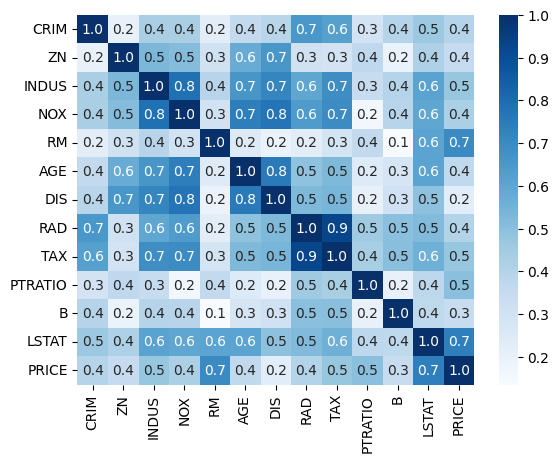

In [11]:
# Gráfico de calor de correlaciones
sns.heatmap(abs(vivienda[var_numerics].corr()), annot=True, fmt='.1f', cmap='Blues')
plt.show()

In [12]:
# Retirando correlaciones altas
# -----
result_df_corr = obtener_correlaciones(vivienda, var_numerics)
result_df_corr.head(15)

,Var1,Var2,Correlation
0,RAD,TAX,0.928195
1,NOX,INDUS,0.785093
2,NOX,AGE,0.742449
3,RM,PRICE,0.696222
4,TAX,NOX,0.692935
5,TAX,INDUS,0.686797
6,INDUS,AGE,0.658919
7,ZN,DIS,0.657429
8,RAD,CRIM,0.652669
9,RAD,NOX,0.639784


In [13]:
# Guardamos las correlaciones
result_df_corr.to_csv('../results/correlations.csv', index=False)

In [14]:
# Filtrar correlaciones altas con PRECIO
var_df_corr = result_df_corr[~(((result_df_corr['Var1'] == 'PRICE') | (result_df_corr['Var2'] == 'PRICE')) & (result_df_corr['Correlation'].abs() >= 0.6))]
var_df_corr.head(15)

,Var1,Var2,Correlation
0,RAD,TAX,0.928195
1,NOX,INDUS,0.785093
2,NOX,AGE,0.742449
4,TAX,NOX,0.692935
5,TAX,INDUS,0.686797
6,INDUS,AGE,0.658919
7,ZN,DIS,0.657429
8,RAD,CRIM,0.652669
9,RAD,NOX,0.639784
10,TAX,CRIM,0.622398


In [15]:
# Filtrar las filas donde "PRICE" aparece en "Variable 1" o "Variable 2"
price_df_corr = result_df_corr[(result_df_corr['Var1'] == 'PRICE') | (result_df_corr['Var2'] == 'PRICE')]
price_df_corr

,Var1,Var2,Correlation
3,RM,PRICE,0.696222
26,PRICE,ZN,0.352278
27,B,PRICE,0.347007
33,PRICE,DIS,0.232413
50,AGE,PRICE,-0.365332
57,CRIM,PRICE,-0.397261
59,RAD,PRICE,-0.404968
61,NOX,PRICE,-0.422701
62,PRICE,TAX,-0.474569
63,PRICE,INDUS,-0.476402


In [16]:
# creamos un nuevo dataframe
# -------

df = vivienda.copy()

# -------

In [17]:
df = df.drop(['RAD', 'NOX'], axis=1)

In [18]:
vivienda.shape, df.shape

((459, 14), (459, 12))

In [19]:
var_numerics.remove('RAD')
var_numerics.remove('NOX')
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE']

Revisando presencia de valores atípicos

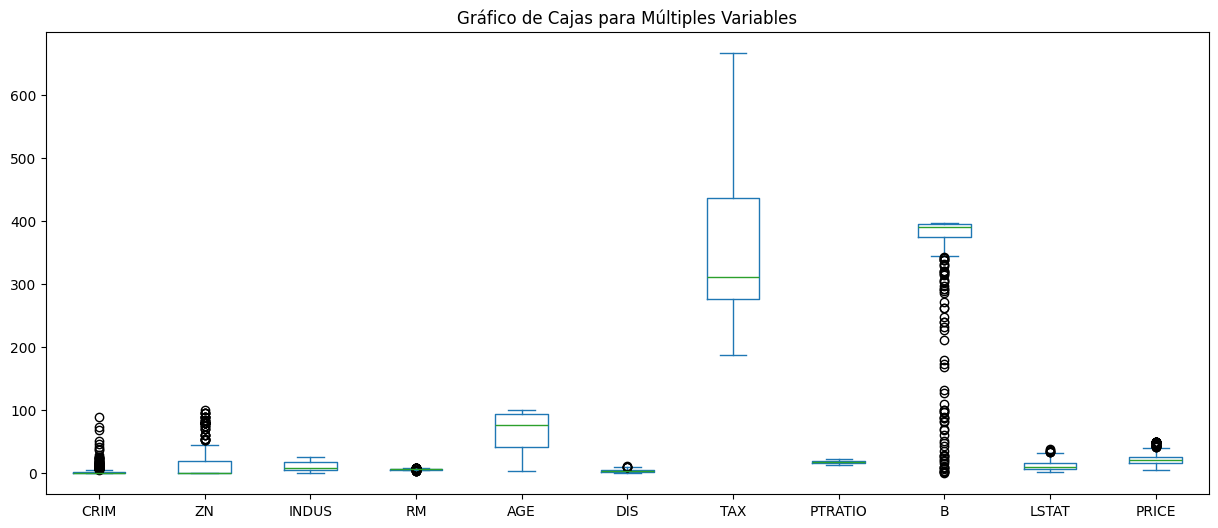

In [20]:
# Crear un gráfico de cajas para todas las variables
df[var_numerics].plot(kind='box', figsize=(15, 6))

# Mostrar el gráfico
plt.title('Gráfico de Cajas para Múltiples Variables')
plt.show()

In [21]:
import sys
sys.path.append("../src")

from outliers import porcentaje_outliers, eliminar_filas_outliers, imputar_valores_extremos

In [22]:
for col in var_numerics:
    perc = porcentaje_outliers(df, col)
    print(f"columna {col} outliers: {perc:.2f}%")

columna CRIM outliers: 18.30%
columna ZN outliers: 9.80%
columna INDUS outliers: 0.00%
columna RM outliers: 6.54%
columna AGE outliers: 0.00%
columna DIS outliers: 1.09%
columna TAX outliers: 0.00%
columna PTRATIO outliers: 0.00%
columna B outliers: 15.25%
columna LSTAT outliers: 1.31%
columna PRICE outliers: 6.75%


In [23]:
# CRIM, RAD, B tienen muchos atipicos, ¿qué tratamiento se les deberia dar?

In [24]:
# Imputando variables con presencia de valores atípicos
# ----

# Imputar valores extremos en la columna 'variable1' usando la mediana
df['ZN_imput'] = df['ZN']
df = imputar_valores_extremos(df, 'ZN_imput', metodo='media')
# ----
var_numerics.append('ZN_imput')
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE',
 'ZN_imput']

In [25]:
for col in var_numerics:
    perc = porcentaje_outliers(df, col)
    print(f"columna {col} outliers: {perc:.2f}%")

columna CRIM outliers: 18.30%
columna ZN outliers: 9.80%
columna INDUS outliers: 0.00%
columna RM outliers: 6.54%
columna AGE outliers: 0.00%
columna DIS outliers: 1.09%
columna TAX outliers: 0.00%
columna PTRATIO outliers: 0.00%
columna B outliers: 15.25%
columna LSTAT outliers: 1.31%
columna PRICE outliers: 6.75%
columna ZN_imput outliers: 12.64%


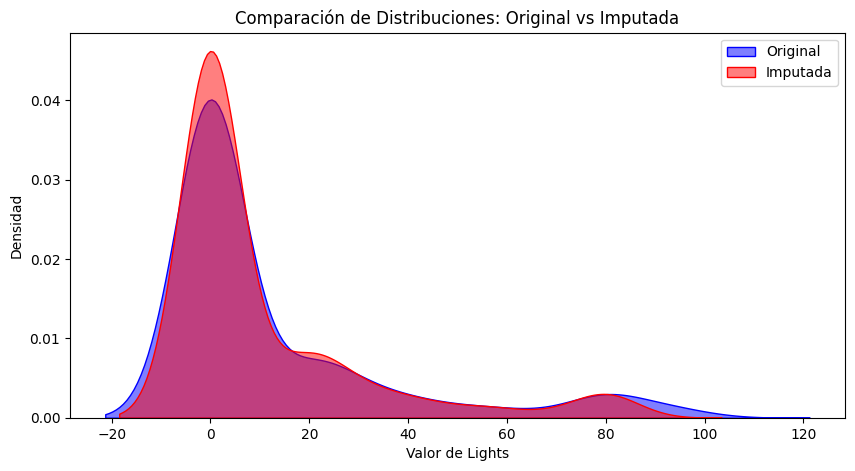

Asimetría Original: 2.0592, Curtosis Original: 3.2361
Asimetría Imputada: 2.1662, Curtosis Imputada: 3.9103


In [26]:
# Calcular asimetría y curtosis antes y después de la imputación
skew_original = skew(df['ZN'], nan_policy='omit')
kurt_original = kurtosis(df['ZN'], nan_policy='omit')

skew_imput = skew(df['ZN_imput'], nan_policy='omit')
kurt_imput = kurtosis(df['ZN_imput'], nan_policy='omit')

# Crear gráfico de distribución comparativo
plt.figure(figsize=(10, 5))
sns.kdeplot(df['ZN'], label='Original', fill=True, color='blue', alpha=0.5)
sns.kdeplot(df['ZN_imput'], label='Imputada', fill=True, color='red', alpha=0.5)

plt.xlabel('Valor de Lights')
plt.ylabel('Densidad')
plt.title('Comparación de Distribuciones: Original vs Imputada')
plt.legend()
plt.show()

# Mostrar métricas
print(f"Asimetría Original: {skew_original:.4f}, Curtosis Original: {kurt_original:.4f}")
print(f"Asimetría Imputada: {skew_imput:.4f}, Curtosis Imputada: {kurt_imput:.4f}")

Winsorización: Limitar los valores extremos a un percentil determinado (por ejemplo, el percentil 95).

In [27]:
from scipy.stats.mstats import winsorize

df['ZN_imput_winsorized'] = winsorize(df['ZN'], limits=[0, 0.05])  # Recorta el 5% superior
# ----
var_numerics.append('ZN_imput_winsorized')
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE',
 'ZN_imput',
 'ZN_imput_winsorized']

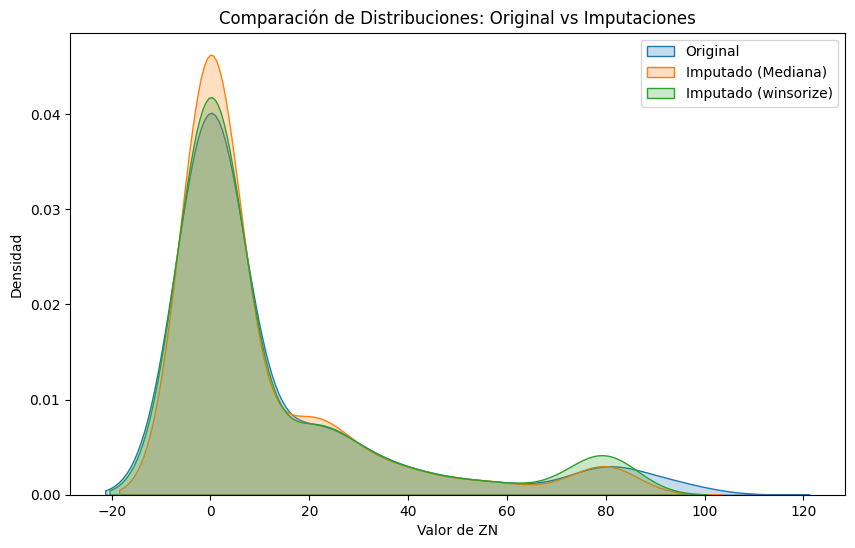

               Variable  Asimetría  Curtosis
0              Original   2.059204  3.236130
1    Imputado (Mediana)   2.166183  3.910348
2  Imputado (winsorize)   1.957646  2.688027


In [28]:
# Lista de variables a analizar
variables = {
    'Original': df['ZN'].dropna(),  # Eliminar NaN antes de calcular métricas
    'Imputado (Mediana)': df['ZN_imput'],
    'Imputado (winsorize)': df['ZN_imput_winsorized']
}

# Crear la figura del gráfico
plt.figure(figsize=(10, 6))

for label, data in variables.items():
    sns.kdeplot(data, label=label, fill=True)

plt.legend()
plt.title("Comparación de Distribuciones: Original vs Imputaciones")
plt.xlabel("Valor de ZN")
plt.ylabel("Densidad")
plt.show()

# Crear tabla con métricas de asimetría y curtosis
metricas = []
for label, data in variables.items():
    metricas.append([label, skew(data, nan_policy='omit'), kurtosis(data, nan_policy='omit')])

df_metricas = pd.DataFrame(metricas, columns=['Variable', 'Asimetría', 'Curtosis'])
print(df_metricas)

In [29]:
for col in var_numerics:
    perc = porcentaje_outliers(df, col)
    print(f"columna {col} outliers: {perc:.2f}%")

columna CRIM outliers: 18.30%
columna ZN outliers: 9.80%
columna INDUS outliers: 0.00%
columna RM outliers: 6.54%
columna AGE outliers: 0.00%
columna DIS outliers: 1.09%
columna TAX outliers: 0.00%
columna PTRATIO outliers: 0.00%
columna B outliers: 15.25%
columna LSTAT outliers: 1.31%
columna PRICE outliers: 6.75%
columna ZN_imput outliers: 12.64%
columna ZN_imput_winsorized outliers: 9.80%


c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [30]:
# Eliminar filas outliers de la columna 'variable1'
df_reduced = df.copy()

df_reduced = eliminar_filas_outliers(df_reduced, 'CRIM')
# df_reduced = eliminar_filas_outliers(df_reduced, 'ZN')
# df_reduced = eliminar_filas_outliers(df_reduced, 'B')

c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [31]:
for col in var_numerics:
    perc = porcentaje_outliers(df, col)
    print(f"columna {col} outliers: {perc:.2f}%")

columna CRIM outliers: 18.30%
columna ZN outliers: 9.80%
columna INDUS outliers: 0.00%
columna RM outliers: 6.54%
columna AGE outliers: 0.00%
columna DIS outliers: 1.09%
columna TAX outliers: 0.00%
columna PTRATIO outliers: 0.00%
columna B outliers: 15.25%
columna LSTAT outliers: 1.31%
columna PRICE outliers: 6.75%
columna ZN_imput outliers: 12.64%
columna ZN_imput_winsorized outliers: 9.80%


c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [32]:
df.shape, df_reduced.shape

((459, 14), (375, 14))

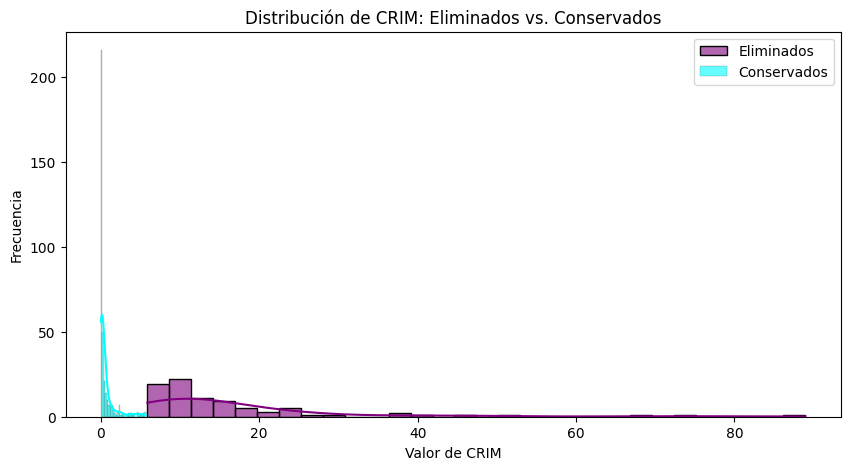

     Métrica   Original  Imputado
0  Asimetría   5.130321  2.799596
1   Curtosis  34.808308  7.486626


In [33]:
# Identificar los registros eliminados
df_removed = df.merge(df_reduced, how='left', indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])

# Crear el histplot para comparar la distribución de CRIM
plt.figure(figsize=(10, 5))
sns.histplot(df_removed["CRIM"], color="purple", label="Eliminados", kde=True, bins=30, alpha=0.6)
sns.histplot(df_reduced["CRIM"], color="cyan", label="Conservados", kde=True, bins=30, alpha=0.6)

# Etiquetas y título
plt.xlabel("Valor de CRIM")
plt.ylabel("Frecuencia")
plt.title("Distribución de CRIM: Eliminados vs. Conservados")
plt.legend()

# Mostrar gráfico
plt.show()

# Calcular métricas estadísticas
original_skew = skew(df["CRIM"], nan_policy='omit')
reduced_skew = skew(df_reduced["CRIM"], nan_policy='omit')

original_kurt = kurtosis(df["CRIM"], fisher=True, nan_policy='omit')  # Fisher=True da kurtosis ajustada (normal=0)
reduced_kurt = kurtosis(df_reduced["CRIM"], fisher=True, nan_policy='omit')

# Mostrar comparación
comparison = pd.DataFrame({
    "Métrica": ["Asimetría", "Curtosis"],
    "Original": [original_skew, original_kurt],
    "Imputado": [reduced_skew, reduced_kurt]
})

print(comparison)

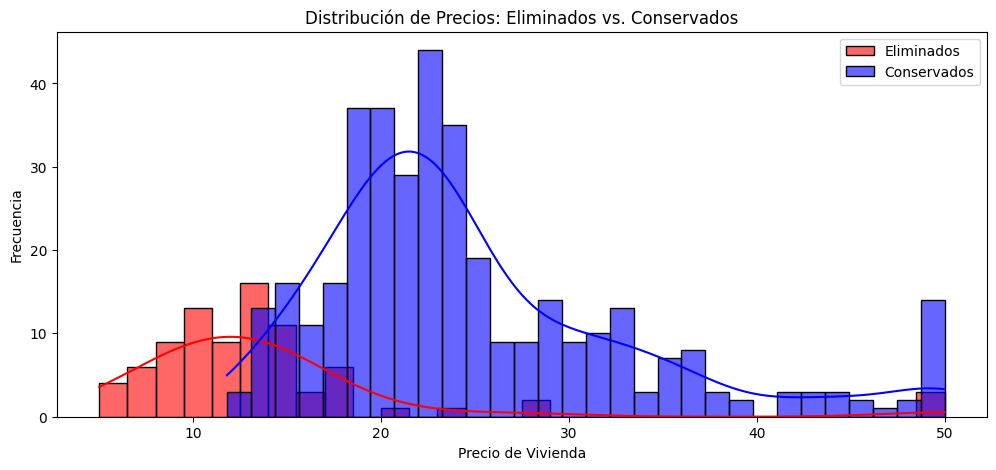

In [34]:
# Crear DataFrame comparativo
stats_removed = df_removed["PRICE"].describe()
stats_reduced = df_reduced["PRICE"].describe()
price_comparison = pd.DataFrame({
    "Métrica": ["Media", "Mediana", "Desviación Estándar", "Mínimo", "Máximo"],
    "Eliminados": [stats_removed["mean"], stats_removed["50%"], stats_removed["std"], stats_removed["min"], stats_removed["max"]],
    "Conservados": [stats_reduced["mean"], stats_reduced["50%"], stats_reduced["std"], stats_reduced["min"], stats_reduced["max"]]
})

plt.figure(figsize=(12,5))
# Histograma de comparación
sns.histplot(df_removed["PRICE"], color="red", label="Eliminados", kde=True, bins=30, alpha=0.6)
sns.histplot(df_reduced["PRICE"], color="blue", label="Conservados", kde=True, bins=30, alpha=0.6)

plt.xlabel("Precio de Vivienda")
plt.ylabel("Frecuencia")
plt.title("Distribución de Precios: Eliminados vs. Conservados")
plt.legend()
plt.show()

In [35]:
# Imputación multiple de datos
# ------------
# Aplicar Isolation Forest
# iso_forest = IsolationForest(contamination=0.1, random_state=42)
# vivienda['scores'] = iso_forest.fit_predict(vivienda)

In [36]:
# Filtrar los datos para eliminar outliers
# df = vivienda[vivienda['scores'] == 1].drop(columns=['scores'])
# df.head()

### Feature Enginering

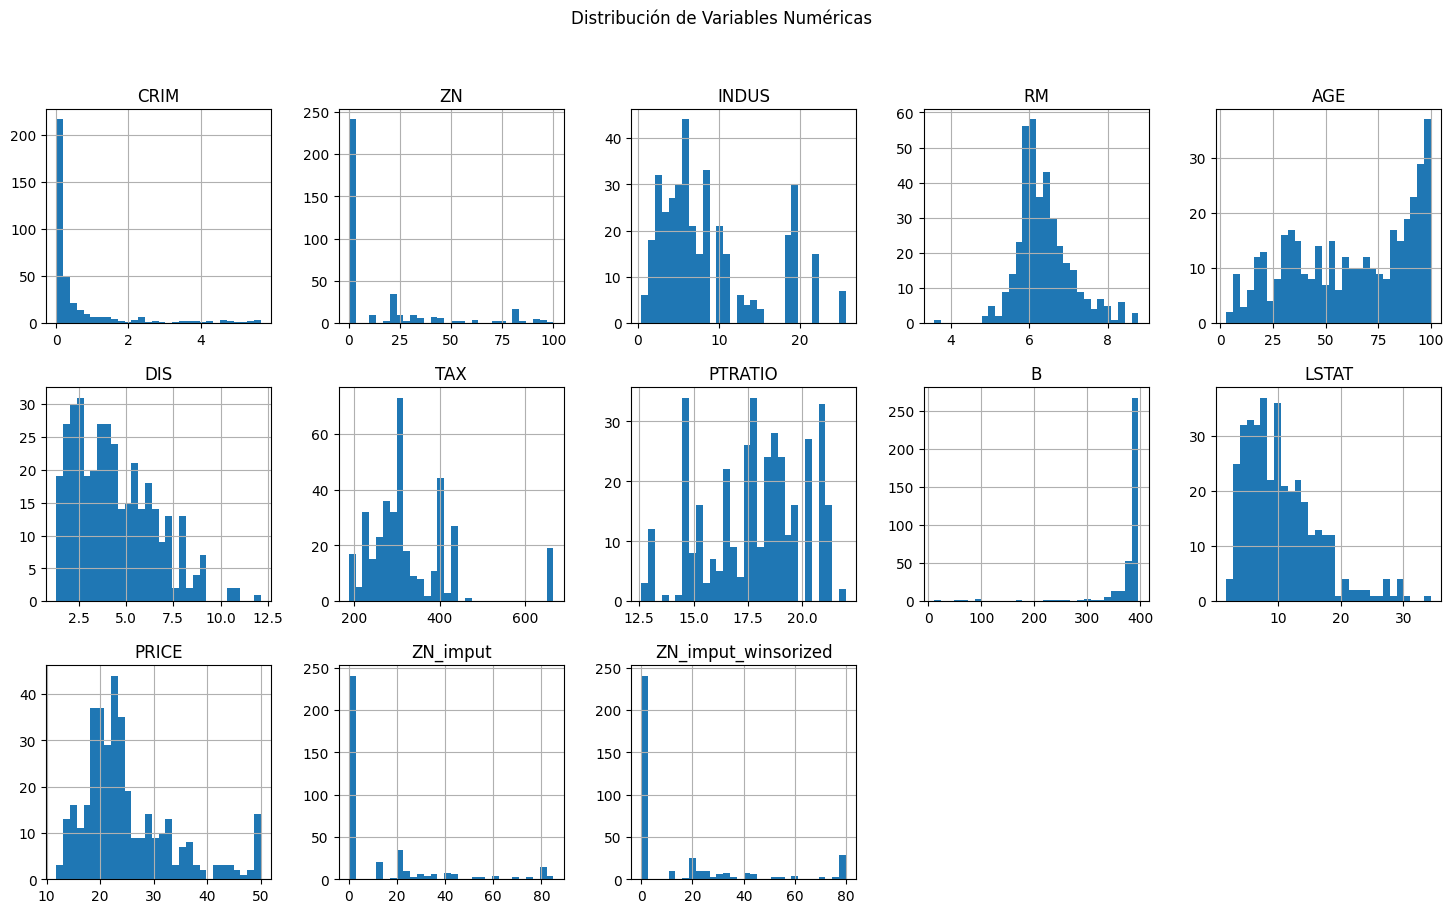

In [37]:
df_reduced[var_numerics].hist(figsize=(18, 10), layout=(3,5), bins=30)
plt.suptitle('Distribución de Variables Numéricas')
plt.show()

**Transformaciones para normalizar distribuciones:**

Algunas variables están sesgadas, lo que puede afectar la calidad del modelo.

In [38]:
import sys
sys.path.append("../src")

from preprocessing import feature_engineering

In [39]:
df_reduced, var_engineering, lambdas = feature_engineering(df_reduced)

In [40]:
var_engineering

['log_CRIM',
 'log_ZN',
 'log_LSTAT',
 'sqrt_DIS',
 'sqrt_INDUS',
 'AGE_boxcox',
 'DIS_boxcox',
 'LSTAT_boxcox']

In [41]:
var_numerics = var_numerics + var_engineering
var_numerics

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE',
 'ZN_imput',
 'ZN_imput_winsorized',
 'log_CRIM',
 'log_ZN',
 'log_LSTAT',
 'sqrt_DIS',
 'sqrt_INDUS',
 'AGE_boxcox',
 'DIS_boxcox',
 'LSTAT_boxcox']

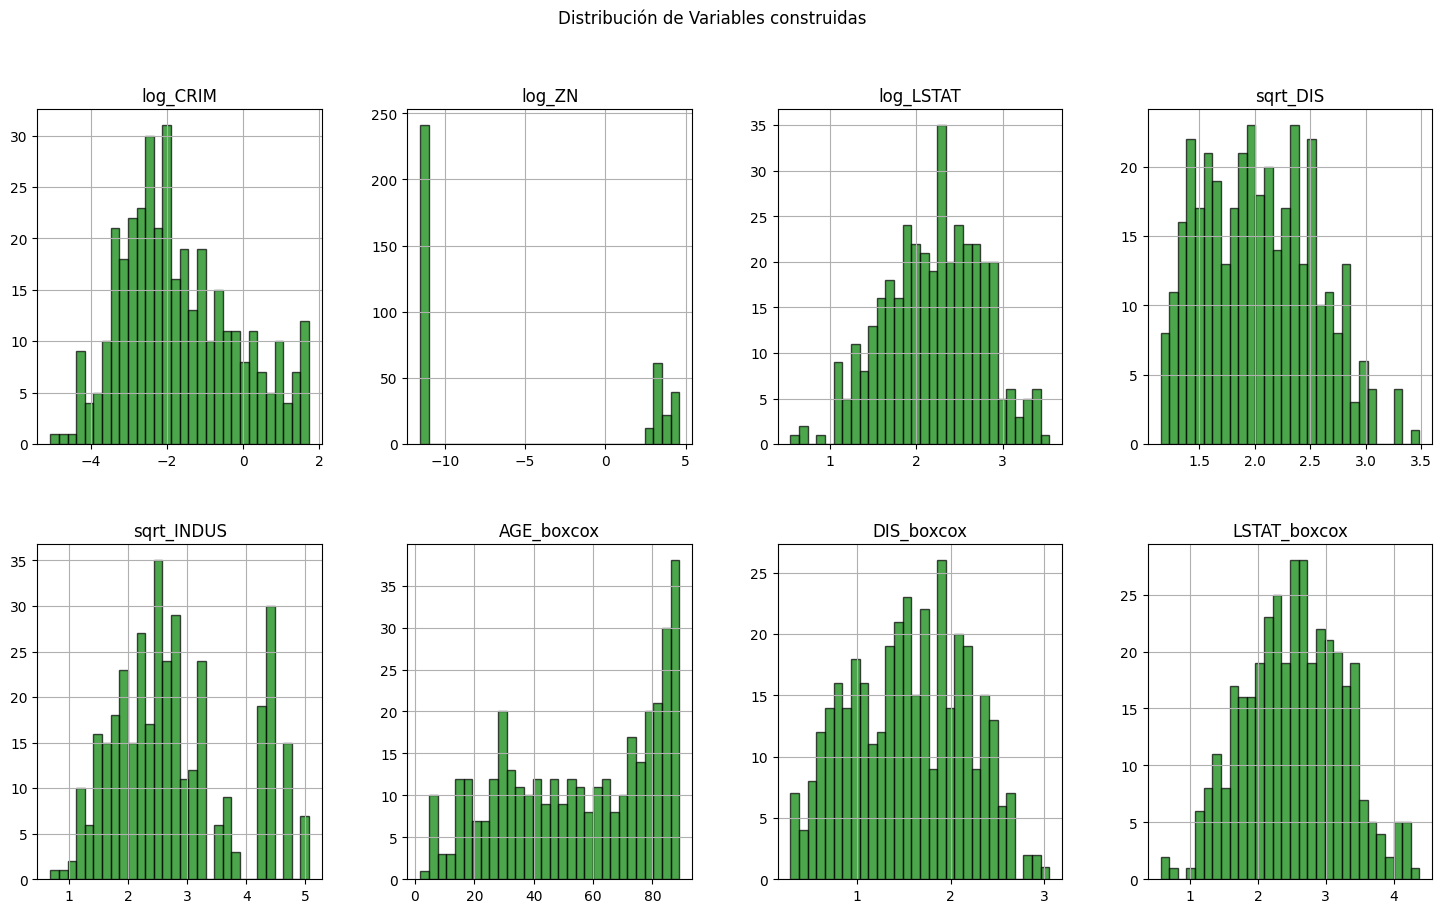

In [42]:
df_reduced[var_engineering].hist(figsize=(18, 10), layout=(2,4), bins=30, color='green', edgecolor='black', alpha=0.7)
plt.suptitle('Distribución de Variables construidas')
plt.show()

In [43]:
vivienda.shape, df_reduced.shape

((459, 14), (375, 22))

In [44]:
var_modeler = var_numerics + ['CHAS']
var_modeler

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'PRICE',
 'ZN_imput',
 'ZN_imput_winsorized',
 'log_CRIM',
 'log_ZN',
 'log_LSTAT',
 'sqrt_DIS',
 'sqrt_INDUS',
 'AGE_boxcox',
 'DIS_boxcox',
 'LSTAT_boxcox',
 'CHAS']

In [45]:
# Definimmos nuestra variable model para utilizar en el modelado
# --------
# ------

# df_model = vivienda
df_model = df_reduced

print(df_model.shape)
df_model

(375, 22)


,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,TAX,PTRATIO,B,...,ZN_imput,ZN_imput_winsorized,log_CRIM,log_ZN,log_LSTAT,sqrt_DIS,sqrt_INDUS,AGE_boxcox,DIS_boxcox,LSTAT_boxcox
0,0.00632,18.0,2.31,0.0,6.575,65.2,4.0900,296.0,15.3,396.90,...,18.0,18.0,-5.062455,2.890372,1.605432,2.022375,1.519868,58.411126,1.577366,1.765389
1,0.02731,0.0,7.07,0.0,6.421,78.9,4.9671,242.0,17.8,396.90,...,0.0,0.0,-3.600136,-11.512925,2.212661,2.228699,2.658947,70.501066,1.823779,2.524035
2,0.02729,0.0,7.07,0.0,7.185,61.1,4.9671,242.0,17.8,392.83,...,0.0,0.0,-3.600869,-11.512925,1.393769,2.228699,2.658947,54.779139,1.823779,1.513311
3,0.03237,0.0,2.18,0.0,6.998,45.8,6.0622,222.0,18.7,394.63,...,0.0,0.0,-3.430214,-11.512925,1.078413,2.462154,1.476482,41.158040,2.084434,1.149085
4,0.06905,0.0,2.18,0.0,7.147,54.2,6.0622,222.0,18.7,396.90,...,0.0,0.0,-2.672780,-11.512925,1.673353,2.462154,1.476482,48.650386,2.084434,1.847606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,5.66637,0.0,18.10,0.0,6.219,100.0,2.0048,666.0,20.2,395.69,...,0.0,0.0,1.734550,-11.512925,2.808801,1.415910,4.254409,89.004391,0.735153,3.322902
451,5.44114,0.0,18.10,0.0,6.655,98.2,2.3552,666.0,20.2,355.29,...,0.0,0.0,1.693990,-11.512925,2.875259,1.534666,4.254409,87.430739,0.917226,3.415447
452,5.09017,0.0,18.10,0.0,6.297,91.8,2.3682,666.0,20.2,385.09,...,0.0,0.0,1.627313,-11.512925,2.848971,1.538896,4.254409,81.828587,0.923530,3.378756
455,4.75237,0.0,18.10,0.0,6.525,86.5,2.4358,666.0,20.2,50.92,...,0.0,0.0,1.558646,-11.512925,2.897569,1.560705,4.254409,77.180681,0.955849,3.446675


# **2. Modelos de regresión**

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
# Al dataset o set de entrenamiento le retiramos la variable dependiente o target
X = df_model.drop("PRICE",axis=1) # covariables
Y = df_model['PRICE'] # target

In [48]:
# Creamos nuestro set de datos
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=20)

### 2.1. Regresión lineal múltiple

In [49]:
import sys
sys.path.append("../src")

from train_model import train_linear_model, get_model_coefficients
from evaluation import calcular_mape, evaluar_modelo

In [50]:
# Entrenamiento
model_reg = train_linear_model(X_train, Y_train)

# Coeficientes
intercepto, coef_df = get_model_coefficients(model_reg, X.columns)

print("Intercepto:", intercepto)
coef_df.head()

# Evaluación
resultados, y_pred_train, y_pred_test = evaluar_modelo(
    model_reg, X_train, X_test, Y_train, Y_test
)

# resultados

Intercepto: 35.59328008829852

 EVALUACIÓN DEL MODELO

Error cuadrático medio (MSE):
Train: 11.9630
Test:  14.9093

Raíz del error cuadrático medio (RMSE):
Train: 3.4588
Test:  3.8613

Error porcentual absoluto medio (MAPE):
Train: 10.24%
Test:  11.88%

Coeficiente de determinación (R²):
Train: 0.8313
Test:  0.8047


### 2.2. Regresión Penalizada : Ridge

In [51]:
import sys
sys.path.append("../src")

from train_model import (generar_alphas, ridge_path, train_ridge_model, predict_ridge)
from evaluation import evaluar_modelo

In [52]:
alphas = generar_alphas()
print(alphas[:10])

[5.00000000e+09 3.87131841e+09 2.99742125e+09 2.32079442e+09
 1.79690683e+09 1.39127970e+09 1.07721735e+09 8.34050269e+08
 6.45774833e+08 5.00000000e+08]


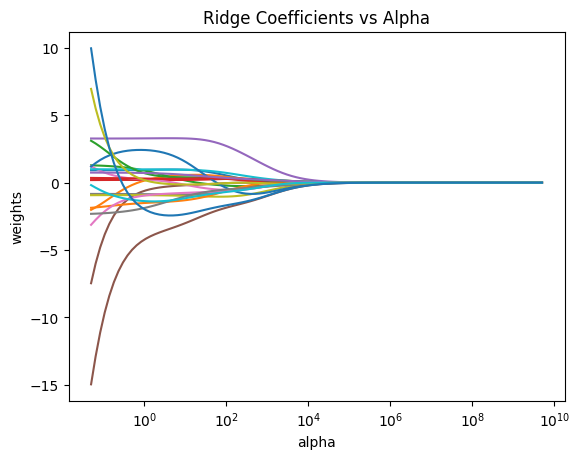

In [53]:
# Graficamos los valores de alpha

coefs, alphas = ridge_path(X, Y, alphas)

import matplotlib.pyplot as plt

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge Coefficients vs Alpha')
plt.show()

In [54]:
# Elegimos el mejor o el valor más óptimo de alpha por Cv

model_ridge, scaler, best_alpha = train_ridge_model(X_train, Y_train, alphas)

print("Mejor alpha:", best_alpha)

Mejor alpha: 8.340502686000313


In [55]:
# Importante: usar datos escalados dentro de evaluación
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

resultados, y_pred_train, y_pred_test = evaluar_modelo(
    model_ridge,
    X_train_scaled,
    X_test_scaled,
    Y_train,
    Y_test
)


 EVALUACIÓN DEL MODELO

Error cuadrático medio (MSE):
Train: 12.4684
Test:  15.8829

Raíz del error cuadrático medio (RMSE):
Train: 3.5311
Test:  3.9853

Error porcentual absoluto medio (MAPE):
Train: 10.42%
Test:  12.58%

Coeficiente de determinación (R²):
Train: 0.8242
Test:  0.7919


### 2.3. Regresión Penalizada : Lasso

In [56]:
import sys
sys.path.append("../src")

from train_model import (generar_alphas, lasso_path, train_lasso_model, predict_lasso)
from evaluation import evaluar_modelo

In [57]:
alphas = generar_alphas()

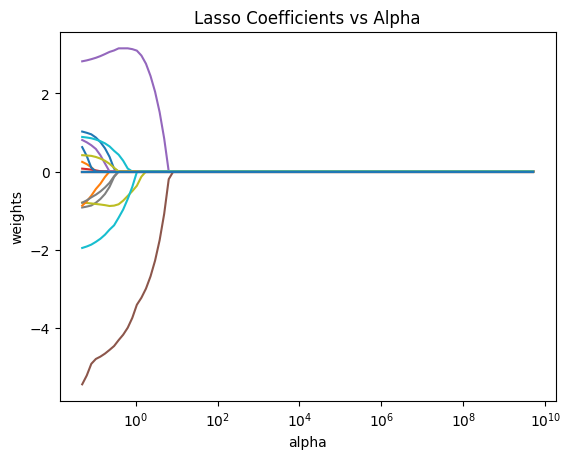

In [58]:
# Escalar primero (como en Ridge)
from sklearn.preprocessing import StandardScaler

scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)

coefs = lasso_path(X_train_scaled, Y_train, alphas)

import matplotlib.pyplot as plt

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Lasso Coefficients vs Alpha')
plt.show()

In [59]:
# Elegimos el mejor o el valor más óptimo de alpha por Cv

model_lasso, scaler, best_alpha = train_lasso_model(X_train, Y_train)

print("Mejor alpha:", best_alpha)

Mejor alpha: 0.018951749044598797


In [60]:
# Importante: usar datos escalados dentro de evaluación
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

resultados, y_pred_train, y_pred_test = evaluar_modelo(
    model_lasso,
    X_train_scaled,
    X_test_scaled,
    Y_train,
    Y_test
)

# resultados


 EVALUACIÓN DEL MODELO

Error cuadrático medio (MSE):
Train: 12.3190
Test:  15.3640

Raíz del error cuadrático medio (RMSE):
Train: 3.5099
Test:  3.9197

Error porcentual absoluto medio (MAPE):
Train: 10.40%
Test:  12.34%

Coeficiente de determinación (R²):
Train: 0.8263
Test:  0.7987


### Analizando los errores en la predicción

In [61]:
import sys
sys.path.append("../src")

from evaluation import analizar_residuos



 ANÁLISIS DE RESIDUOS

Media de residuos: 0.0000
Desviación estándar: 3.5099
Asimetría (skewness): 0.4571
Curtosis: 4.8191


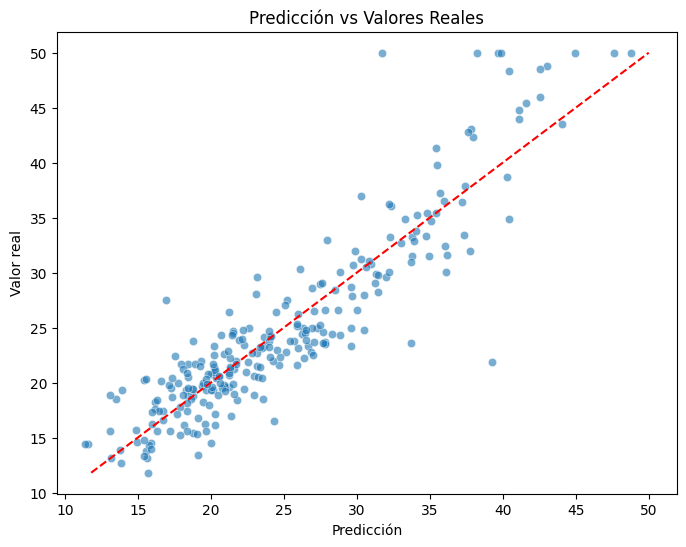

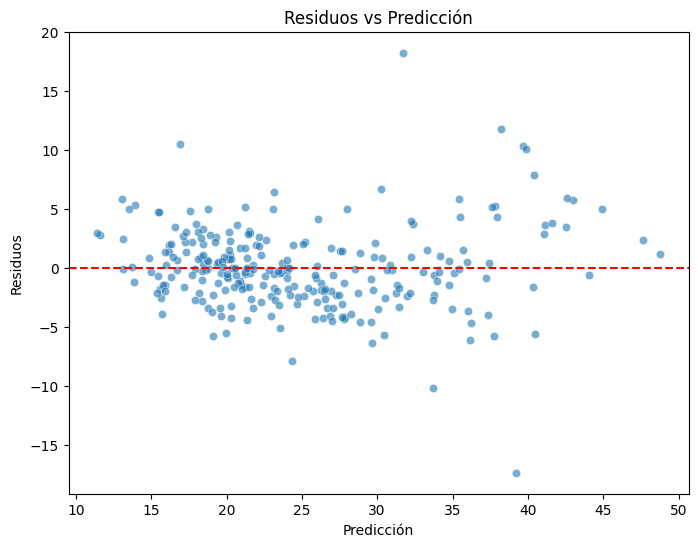

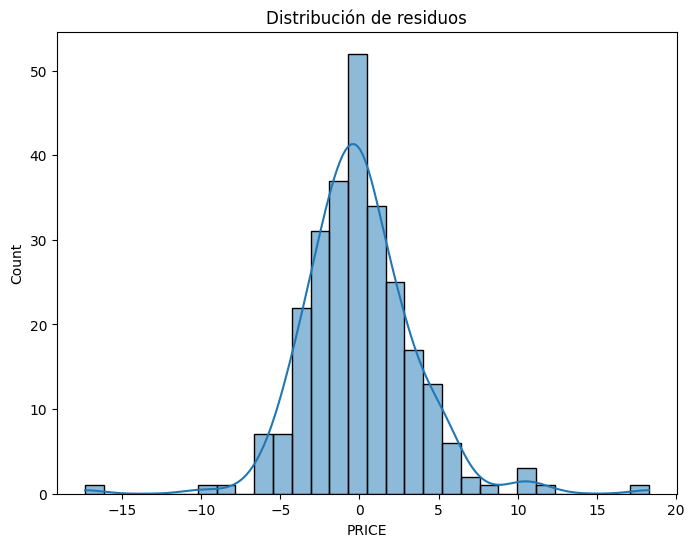

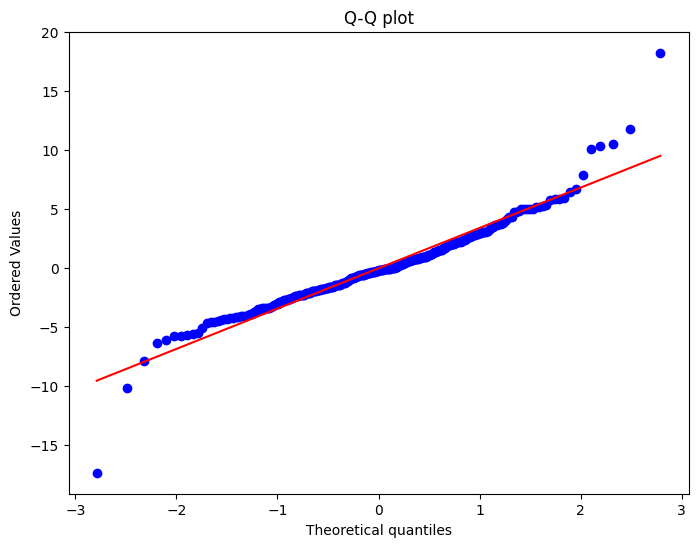

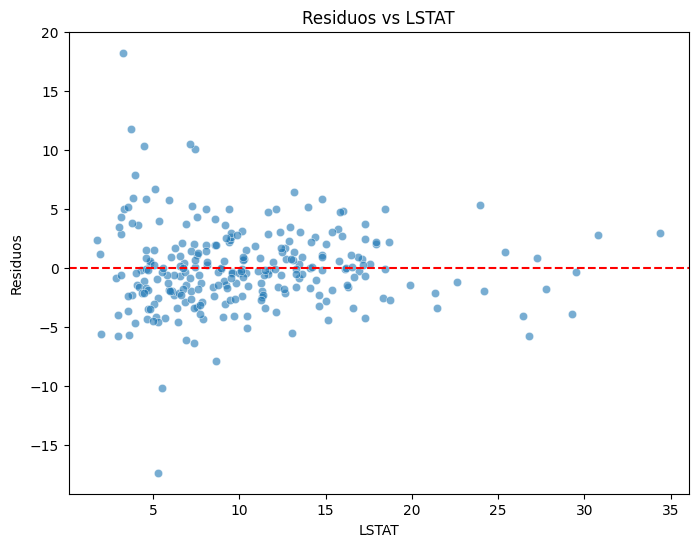

In [62]:
residuos = analizar_residuos(
    y_true=Y_train,
    y_pred=y_pred_train,
    feature=X_train["LSTAT"],   # opcional
    feature_name="LSTAT"
)

### 5. Guardando los modelos para un uso posterior

In [63]:
import sys
sys.path.append("../src")

from train_model import guardar_modelo

In [64]:
# Guardando el modelo Lineal Regresion
# ------
guardar_modelo(model_reg, nombre_modelo="linear_regression")

 Modelo guardado en: c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\House-Price-Prediction-with-Machine-Learning\models\linear_regression_20260520_214705.pkl


'c:\\cesar_quezada\\ProyectosIA\\03. Proyectos_SOLUCIONES_DIG\\House-Price-Prediction-with-Machine-Learning\\models\\linear_regression_20260520_214705.pkl'

In [65]:
# Guardando el modelo ridge
# ------
guardar_modelo(model_ridge, nombre_modelo="ridge")

 Modelo guardado en: c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\House-Price-Prediction-with-Machine-Learning\models\ridge_20260520_214705.pkl


'c:\\cesar_quezada\\ProyectosIA\\03. Proyectos_SOLUCIONES_DIG\\House-Price-Prediction-with-Machine-Learning\\models\\ridge_20260520_214705.pkl'

In [66]:
# Guardando el modelo lasso
# ------
guardar_modelo(model_lasso, nombre_modelo="lasso")

 Modelo guardado en: c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\House-Price-Prediction-with-Machine-Learning\models\lasso_20260520_214705.pkl


'c:\\cesar_quezada\\ProyectosIA\\03. Proyectos_SOLUCIONES_DIG\\House-Price-Prediction-with-Machine-Learning\\models\\lasso_20260520_214705.pkl'

# **3. Qué podemos hacer con nuestro modelo?**

In [67]:
import sys
sys.path.append("../src")

from evaluation import (
    detectar_viviendas_subvaloradas,
    plot_subvaloradas
)

from train_model import cargar_modelo

In [68]:
# Cargando el modelo ganador
model = cargar_modelo("linear_regression_20260404_224424.pkl")

 Modelo cargado correctamente desde:
c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\House-Price-Prediction-with-Machine-Learning\models\linear_regression_20260404_224424.pkl


In [69]:
# Limpiando variables explicativas
var_modeler.remove('PRICE')
var_modeler

['CRIM',
 'ZN',
 'INDUS',
 'RM',
 'AGE',
 'DIS',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'ZN_imput',
 'ZN_imput_winsorized',
 'log_CRIM',
 'log_ZN',
 'log_LSTAT',
 'sqrt_DIS',
 'sqrt_INDUS',
 'AGE_boxcox',
 'DIS_boxcox',
 'LSTAT_boxcox',
 'CHAS']

In [70]:
scaler.feature_names_in_

array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'RM', 'AGE', 'DIS', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'ZN_imput', 'ZN_imput_winsorized',
       'log_CRIM', 'log_ZN', 'log_LSTAT', 'sqrt_DIS', 'sqrt_INDUS',
       'AGE_boxcox', 'DIS_boxcox', 'LSTAT_boxcox'], dtype=object)

In [71]:
# Generando predicciones para la data analizada
features = scaler.feature_names_in_
X_scaled = scaler.transform(X[features])
y_pred = model.predict(X_scaled)

c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Detectar oportunidades

In [72]:
subvaloradas = detectar_viviendas_subvaloradas(
    X[features],
    Y,
    y_pred
)
subvaloradas.head()

,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,TAX,PTRATIO,B,...,log_LSTAT,sqrt_DIS,sqrt_INDUS,AGE_boxcox,DIS_boxcox,LSTAT_boxcox,PRICE_REAL,PRICE_PRED,ERROR,PORCENTAJE_SUBVALORACION
364,3.47428,0.0,18.10,1.0,8.780,82.9,1.9047,666.0,20.2,354.55,...,1.665820,1.380109,4.254409,74.018889,0.678221,1.838455,21.9,73.869634,51.969634,237.304263
40,0.03359,75.0,2.95,0.0,7.024,15.8,5.4011,252.0,18.3,395.62,...,0.683102,2.324027,1.717556,13.983897,1.932370,0.711015,34.9,97.221659,62.321659,178.572089
308,0.49298,0.0,9.90,0.0,6.635,82.5,3.3175,304.0,18.4,396.90,...,1.512929,1.821401,3.146427,73.667334,1.320195,1.654459,22.8,61.344196,38.544196,169.053492
251,0.21409,22.0,5.86,0.0,6.438,8.9,7.3967,330.0,19.1,377.07,...,1.278155,2.719687,2.420744,7.570272,2.353037,1.378225,24.8,63.761840,38.961840,157.104192
290,0.03502,80.0,4.95,0.0,6.861,27.9,5.1167,245.0,19.2,396.90,...,1.202975,2.262012,2.224860,25.044827,1.862082,1.291354,28.5,72.456031,43.956031,154.231687


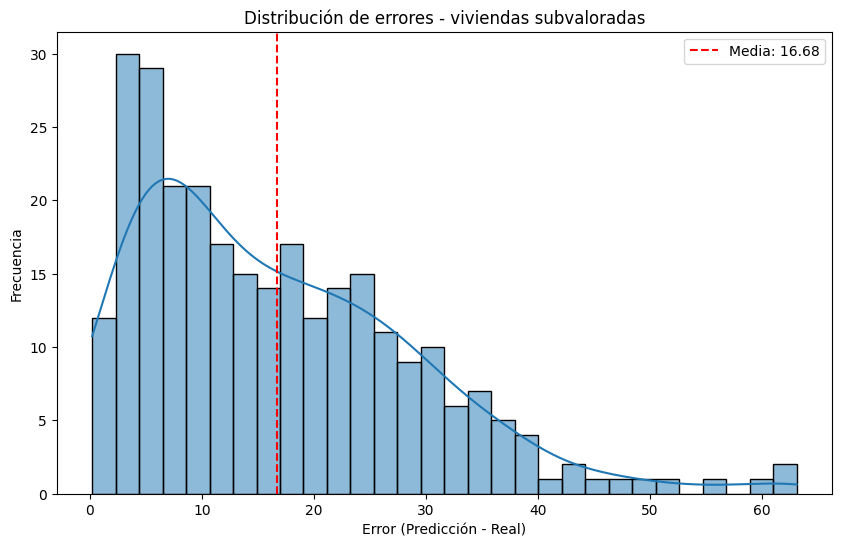

In [73]:
plot_subvaloradas(subvaloradas)

Top oportunidades

In [74]:
subvaloradas[
    [
        'PRICE_REAL',
        'PRICE_PRED',
        'ERROR',
        'PORCENTAJE_SUBVALORACION'
    ]
].head(10)

,PRICE_REAL,PRICE_PRED,ERROR,PORCENTAJE_SUBVALORACION
364,21.9,73.869634,51.969634,237.304263
40,34.9,97.221659,62.321659,178.572089
308,22.8,61.344196,38.544196,169.053492
251,24.8,63.761840,38.961840,157.104192
290,28.5,72.456031,43.956031,154.231687
275,32.0,78.734254,46.734254,146.044543
88,23.6,57.400993,33.800993,143.224545
0,24.0,58.049164,34.049164,141.871518
3,33.4,78.641039,45.241039,135.452214
232,41.7,97.412820,55.712820,133.603884


### ¿Cuanto costará una nueva vivienda?

In [75]:
vivienda_new = pd.read_csv(
    "../data/raw/vivienda_new.csv",
    sep=";"
)

In [76]:
vivienda_new.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,459,6.80117,0,18.1,0,0.713,6.081,84.4,2.7175,24,666,20.2,396.90,14.70
1,460,4.81213,0,18.1,0,0.713,6.701,90.0,2.5975,24,666,20.2,255.23,16.42
2,461,3.69311,0,18.1,0,0.713,6.376,88.4,2.5671,24,666,20.2,391.43,14.65
3,462,6.65492,0,18.1,0,0.713,6.317,83.0,2.7344,24,666,20.2,396.90,13.99
4,463,5.82115,0,18.1,0,0.713,6.513,89.9,2.8016,24,666,20.2,393.82,10.29


Realizamos la limpieza de datos

In [78]:
import sys
sys.path.append("../src")


In [81]:
from preprocessing import preparar_nueva_data
from train_model import cargar_modelo

In [82]:
vivienda_new = preparar_nueva_data(vivienda_new)

In [83]:
vivienda_new.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,TAX,PTRATIO,...,ZN_imput,ZN_imput_winsorized,log_CRIM,log_ZN,log_LSTAT,sqrt_DIS,sqrt_INDUS,AGE_boxcox,DIS_boxcox,LSTAT_boxcox
0,459,6.80117,0,18.1,0,6.081,84.4,2.7175,666,20.2,...,0.0,0,1.917096,-11.512925,2.687848,1.648484,4.254409,12485.657255,0.918233,4.551469
1,460,4.81213,0,18.1,0,6.701,90.0,2.5975,666,20.2,...,0.0,0,1.571142,-11.512925,2.798501,1.611676,4.254409,14488.589691,0.880078,4.850747
2,461,3.69311,0,18.1,0,6.376,88.4,2.5671,666,20.2,...,0.0,0,1.306472,-11.512925,2.684441,1.602217,4.254409,13899.028717,0.870083,4.542443
3,462,6.65492,0,18.1,0,6.317,83.0,2.7344,666,20.2,...,0.0,0,1.895358,-11.512925,2.638344,1.653602,4.254409,12011.232984,0.923448,4.421416
4,463,5.82115,0,18.1,0,6.513,89.9,2.8016,666,20.2,...,0.0,0,1.761500,-11.512925,2.331174,1.673798,4.254409,14451.334121,0.943815,3.664611


Cargamos el modelo

In [84]:
# Cargando el modelo ganador
model = cargar_modelo("linear_regression_20260404_224424.pkl")

 Modelo cargado correctamente desde:
c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\House-Price-Prediction-with-Machine-Learning\models\linear_regression_20260404_224424.pkl


In [86]:
features = scaler.feature_names_in_
X_scaled_new = scaler.transform(vivienda_new[features])

In [88]:
y_pred_new = model.predict(X_scaled_new)
vivienda_new["PRICE_PRED"] = y_pred_new
vivienda_new.head(5)

c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,TAX,PTRATIO,...,ZN_imput_winsorized,log_CRIM,log_ZN,log_LSTAT,sqrt_DIS,sqrt_INDUS,AGE_boxcox,DIS_boxcox,LSTAT_boxcox,PRICE_PRED
0,459,6.80117,0,18.1,0,6.081,84.4,2.7175,666,20.2,...,0,1.917096,-11.512925,2.687848,1.648484,4.254409,12485.657255,0.918233,4.551469,1454.076769
1,460,4.81213,0,18.1,0,6.701,90.0,2.5975,666,20.2,...,0,1.571142,-11.512925,2.798501,1.611676,4.254409,14488.589691,0.880078,4.850747,1677.823322
2,461,3.69311,0,18.1,0,6.376,88.4,2.5671,666,20.2,...,0,1.306472,-11.512925,2.684441,1.602217,4.254409,13899.028717,0.870083,4.542443,1604.472569
3,462,6.65492,0,18.1,0,6.317,83.0,2.7344,666,20.2,...,0,1.895358,-11.512925,2.638344,1.653602,4.254409,12011.232984,0.923448,4.421416,1401.570428
4,463,5.82115,0,18.1,0,6.513,89.9,2.8016,666,20.2,...,0,1.761500,-11.512925,2.331174,1.673798,4.254409,14451.334121,0.943815,3.664611,1647.935154
